# Trabalho 5 – Regressão SVM com PCA

## Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Preparando a base de dados

In [3]:
StudantPerformance_df = pd.read_csv('Student_Performance.csv')

StudantPerformance_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Convertendo a variável categórica (Extracurricular Activities) para 0 e 1

0 -> Não \
1 -> Sim

In [4]:
col = 'Extracurricular Activities'
if StudantPerformance_df[col].dropna().isin(['Yes', 'No']).all():
    StudantPerformance_df[col] = StudantPerformance_df[col].map({'Yes': 1, 'No': 0})

StudantPerformance_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


Verificando colunas com valores nulos

In [5]:
print(StudantPerformance_df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


Pegando apenas uma pequena amostra dos dados para o teste inicial do algorítmo

In [ ]:
sample_df = StudantPerformance_df.sample(n=1000, random_state=42).reset_index(drop=True)
sample_df.shape

(1000, 6)

### Pairplot dos parametros:

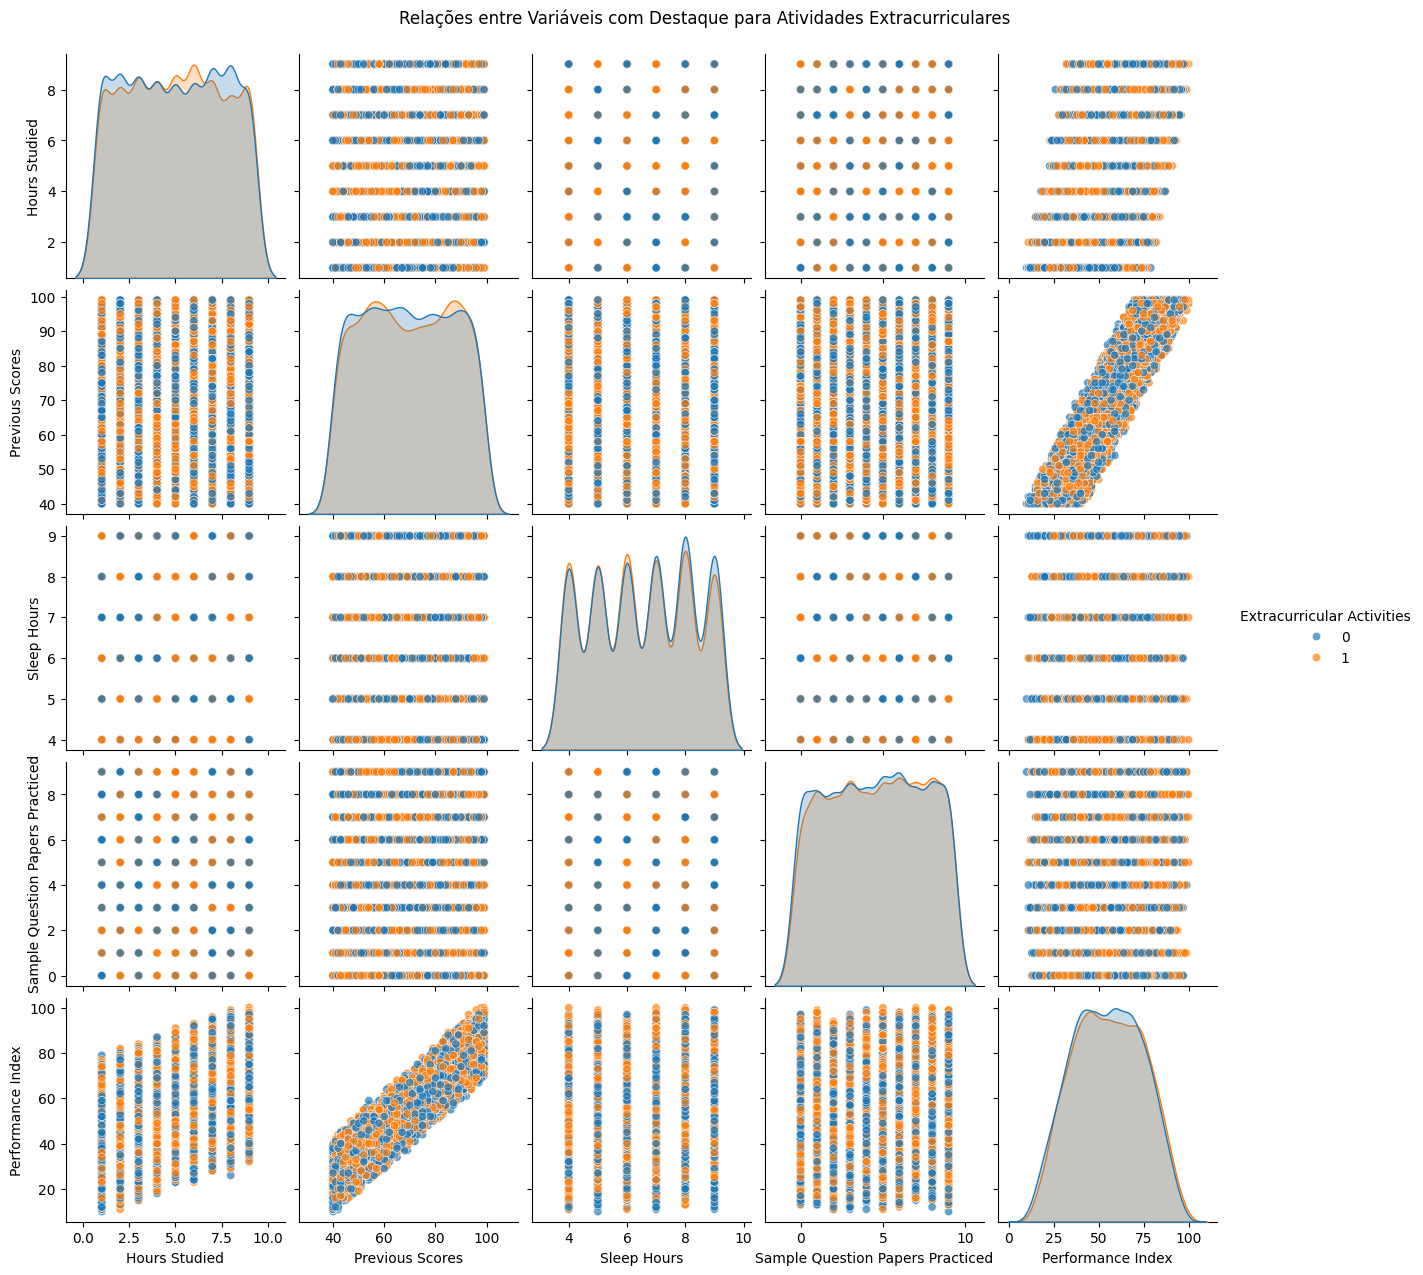

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


# Faz o pairplot sem a coluna 'Extracurricular Activities',
# mas usa essa coluna como hue para colorir os pontos
sns.pairplot(
    StudantPerformance_df[[
        'Hours Studied',
        'Previous Scores',
        'Sleep Hours',
        'Sample Question Papers Practiced',
        'Performance Index',
        'Extracurricular Activities'
    ]],
    hue='Extracurricular Activities',
    plot_kws={'alpha': 0.7} 
)

plt.suptitle("Relações entre Variáveis com Destaque para Atividades Extracurriculares", y=1.02)
plt.show()


Como muitos dados são inteiros, é meio complicado visualizar os gráficos de disperção (os pontos se sobrepõem).

### Otimizando hiperparâmetros

Usando holdout para reduzir o tempo de execução

In [8]:
# Separando X e y
X = sample_df.drop('Performance Index', axis=1).values
y = sample_df['Performance Index'].values

# Hold-Out (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Normalizando com base no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid de hiperparâmetros
kernels = ['linear', 'rbf', 'poly']
Cs = [1e-2, 1e-1, 1, 10, 100]
gammas = [1e-2, 1e-1, 1, 10, 100]

results = []

for kernel in kernels:
    for C in Cs:
        if kernel == 'linear':
            model = SVR(kernel=kernel, C=C)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            mse = mean_squared_error(y_test, y_pred)
            results.append({'kernel': kernel, 'C': C, 'gamma': 'N/A', 'mse': mse})
        else:
            for gamma in gammas:
                if kernel == 'poly':
                    model = SVR(kernel=kernel, C=C, gamma=gamma, degree=2)
                else:
                    model = SVR(kernel=kernel, C=C, gamma=gamma)
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                results.append({'kernel': kernel, 'C': C, 'gamma': gamma, 'mse': mse})

# Ordena pelo menor MSE
results = sorted(results, key=lambda x: x['mse'])

# Exibe os top 5
print("Top 5 combinações com menor MSE (Hold-Out):")
for r in results[:5]:
    print(r)


Top 5 combinações com menor MSE (Hold-Out):
{'kernel': 'rbf', 'C': 100, 'gamma': 0.01, 'mse': 3.738457346852607}
{'kernel': 'linear', 'C': 1, 'gamma': 'N/A', 'mse': 5.232609207237591}
{'kernel': 'linear', 'C': 10, 'gamma': 'N/A', 'mse': 5.864948917127103}
{'kernel': 'linear', 'C': 100, 'gamma': 'N/A', 'mse': 5.972921417356815}
{'kernel': 'rbf', 'C': 10, 'gamma': 0.1, 'mse': 11.442885287196644}


### Implementação do SVM isolado

In [ ]:

def SVM_d

# Treinando o SVR final com os melhores hiperparâmetros
best_model = SVR(kernel='rbf', C=100, gamma=0.01)
best_model.fit(X_train_scaled, y_train)

# Fazendo previsões
y_pred = best_model.predict(X_test_scaled)

# Avaliando o modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Avaliação do SVR Final (sem PCA):")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")


🔍 Avaliação do SVR Final (sem PCA):
MSE: 3.3563
R²: 0.9909
